# 7.4 — LMM: simulación completa y Bermudan swaption vía Longstaff-Schwartz

Cierre del módulo M7: una simulación LMM completa (medida terminal, vol bucketizada +
correlación de Rebonato calibradas en 7.3) para valuar una **Bermudan swaption** — el
derecho a entrar en el mismo swap subyacente en una de varias fechas posibles, no sólo
una. El estado relevante (todas las tasas forward vivas) es de alta dimensión: una
retícula (como en 3.4) es inviable, pero Longstaff-Schwartz (4.4) no le importa la
dimensión del estado subyacente, sólo necesita una base de regresión razonable.

## 0. Configuración

Misma malla que 7.1-7.3: $\tau=0.5$, $N=10$ tasas forward $L_0,\dots,L_9$
($L_i$ fija en $T_i=\tau(i+1)$, paga en $T_{i+1}$). Bootstrap de vol instantánea y
correlación de Rebonato **redefinidos localmente** (idénticos a 7.3, mismos parámetros
$\rho_\infty=0.30,\beta=0.10$) — 7.4 no depende de que 7.3 se haya ejecutado antes en el
mismo kernel.

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, synthetic_cap_vols, synthetic_swaption_vols
from qflib.lsm import longstaff_schwartz
from qflib.mc import mc_estimate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

tau = 0.5
N = 10
T = np.array([tau * (i + 1) for i in range(N + 1)])
L0 = np.array([(nelson_siegel_df(T[i]) / nelson_siegel_df(T[i + 1]) - 1.0) / tau for i in range(N)])

# bootstrap de vol instantánea (7.3, Sección 1)
cap_vols_atm = np.array([
    synthetic_cap_vols(np.array([L0[i]]), np.array([T[i + 1]]))[0, 0] for i in range(N)
])
b = np.zeros(N)
for i in range(N):
    var_target = cap_vols_atm[i] ** 2 * T[i]
    var_known = tau * np.sum(b[:i] ** 2)
    b[i] = np.sqrt((var_target - var_known) / tau)

# correlacion de Rebonato (7.3, Seccion 2)
def rebonato_correlation(rho_inf, beta, T_fix):
    d = np.abs(T_fix[:, None] - T_fix[None, :])
    return rho_inf + (1.0 - rho_inf) * np.exp(-beta * d)

rho_inf, beta = 0.30, 0.10
rho = rebonato_correlation(rho_inf, beta, T[:N])
chol = np.linalg.cholesky(rho)  # confirma PSD (ya validado en 7.3)

print("niveles de bucket b:", np.round(b, 5))
print("correlacion PSD (cholesky ok):", chol.shape)

niveles de bucket b: [0.18118 0.17153 0.16621 0.16278 0.16036 0.15855 0.1571  0.15589 0.15484
 0.15389]
correlacion PSD (cholesky ok): (10, 10)


## 1. La Bermudan swaption

Swap subyacente: paga hasta $T_8=4.5$ (fijo), tasa fija $K$ = tasa par ATM de la
primera oportunidad de ejercicio. **Fechas de ejercicio**: $t_n = n\tau$ para
$n\in\{3,4,5,6\}$ (es decir, $T_2,T_3,T_4,T_5 = 1.5, 2.0, 2.5, 3.0$ años) — en cada una,
el tenedor puede entrar en el swap remanente desde $t_n$ hasta $T_8$. Notación: simular
$n$ periodos de longitud $\tau$ deja el reloj exactamente en $t=n\tau$ (bucket $m=0,\dots,
n-1$ ya transcurrido), y en ese instante $L_{n-1}$ acaba de fijar — la primera tasa viva
del swap que empieza en $t_n$ es $L_n$.

In [2]:
BETA_N = 8  # el swap siempre paga hasta T[8]=4.5
N_EX = np.array([3, 4, 5, 6])  # fechas de ejercicio, en "numero de periodos tau" transcurridos

# tasa par ATM (t=0) del swap que empieza en la primera fecha de ejercicio
P = np.ones(N + 1)
for k in range(1, N + 1):
    P[k] = P[k - 1] / (1.0 + tau * L0[k - 1])
annuity0 = tau * np.sum(P[N_EX[0] + 1:BETA_N + 1])
K = (P[N_EX[0]] - P[BETA_N]) / annuity0
P0N = nelson_siegel_df(T[N])

print(f"K (tasa par ATM, swap {N_EX[0]*tau}x{T[BETA_N]-N_EX[0]*tau}): {K:.5%}")
print(f"fechas de ejercicio (anos): {N_EX * tau}")

K (tasa par ATM, swap 1.5x3.0): 4.65691%
fechas de ejercicio (anos): [1.5 2.  2.5 3. ]


## 2. Simulación LMM bajo la medida terminal, con checkpoints en cada fecha de ejercicio

Una sola simulación, guardando el estado de las 10 tasas forward en cada una de las 4 fechas de ejercicio posibles — Longstaff-Schwartz necesita las MISMAS trayectorias en todas las fechas de decisión para poder comparar "ejercer ahora" contra "seguir esperando" en cada una.

In [3]:
def simulate_lmm_checkpoints(L0, b, rho, tau, n_periods_total, n_steps_per_period, n_paths, rng, checkpoints):
    '''Simula L_0..L_{N-1} bajo Q^{T_N}, vol bucketizada + correlacion rho, log-Euler.
    Devuelve {n: L(t=n*tau)} para cada n en checkpoints (mismas trayectorias en todos).'''
    N_ = len(L0)
    chol_ = np.linalg.cholesky(rho)
    L = np.tile(L0, (n_paths, 1)).astype(float)
    dt = tau / n_steps_per_period
    out = {}
    for m in range(n_periods_total):
        sigma_t = np.array([b[i - m] if i >= m else 0.0 for i in range(N_)])
        for _ in range(n_steps_per_period):
            Z = rng.standard_normal((n_paths, N_))
            dW = (Z @ chol_.T) * np.sqrt(dt)
            drift = np.zeros((n_paths, N_))
            for i in range(N_ - 1):
                if sigma_t[i] == 0.0:
                    continue
                active = sigma_t[i + 1:] > 0.0
                s = np.sum(
                    tau * rho[i, i + 1:][active] * sigma_t[i + 1:][active] * L[:, i + 1:][:, active]
                    / (1.0 + tau * L[:, i + 1:][:, active]), axis=1)
                drift[:, i] = -sigma_t[i] * L[:, i] * s
            L = L * np.exp((drift - 0.5 * sigma_t ** 2) * dt + sigma_t * dW)
        if (m + 1) in checkpoints:
            out[m + 1] = L.copy()
    return out


def ratio_from_L(L, N_, tau):
    '''ratio[:,k] = P(t,T_k)/P(t,T_N), a partir de las tasas forward vivas/fijas en L.'''
    n_paths_ = L.shape[0]
    ratio = np.ones((n_paths_, N_ + 1))
    for k in range(N_ - 1, -1, -1):
        ratio[:, k] = ratio[:, k + 1] * (1.0 + tau * L[:, k])
    return ratio


def swap_rate_and_deflated_annuity(L, n, beta_n, N_, tau):
    ratio = ratio_from_L(L, N_, tau)
    ann_over_N = tau * np.sum(ratio[:, n + 1:beta_n + 1], axis=1)
    S = (ratio[:, n] - ratio[:, beta_n]) / ann_over_N
    return S, ann_over_N


n_paths = 100_000
checkpoints = simulate_lmm_checkpoints(L0, b, rho, tau, n_periods_total=N_EX.max(),
                                        n_steps_per_period=4, n_paths=n_paths, rng=rng,
                                        checkpoints=set(N_EX))
print(f"simuladas {n_paths} trayectorias con checkpoints en n={list(N_EX)}")

simuladas 100000 trayectorias con checkpoints en n=[np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


### Demo 1 — swaption europea (mejor fecha) vía MC directo, control contra Black-76

Antes de valuar la Bermudan (el derecho a elegir entre las 4 fechas), primero valuamos cada oportunidad de ejercicio como si fuera una swaption EUROPEA independiente — vía MC directo sobre las trayectorias ya simuladas — y comparamos la mejor de las 4 contra Black-76 usando la vol de Rebonato calibrada en 7.3, el mismo control de consistencia de esa notebook.

In [4]:
def par_swap_weights(alpha, beta_n, L0, T, tau):
    P_ = np.ones(len(T))
    for k in range(1, len(T)):
        P_[k] = P_[k - 1] / (1.0 + tau * L0[k - 1])
    Ps = P_[alpha + 1:beta_n + 1]
    annuity = tau * np.sum(Ps)
    w = tau * Ps / annuity
    S0_ = np.sum(w * L0[alpha:beta_n])
    return w, S0_, annuity


def flat_vol_to_horizon(i, horizon_periods, b, tau):
    var = 0.0
    for m in range(horizon_periods):
        k = i - m
        if k >= 0:
            var += b[k] ** 2 * tau
    return np.sqrt(var / (horizon_periods * tau)) if var > 0.0 else 0.0


def rebonato_swaption_vol(alpha, beta_n, L0, T, tau, b, rho):
    w, S0_, annuity = par_swap_weights(alpha, beta_n, L0, T, tau)
    idx = np.arange(alpha, beta_n)
    sigma_h = np.array([flat_vol_to_horizon(i, alpha, b, tau) for i in idx])
    rho_sub = rho[np.ix_(idx, idx)]
    num = np.sum(np.outer(w * L0[idx] * sigma_h, w * L0[idx] * sigma_h) * rho_sub)
    return np.sqrt(num / S0_ ** 2), S0_, annuity


def black76_price(F, K_, T_exp, vol, annuity):
    if vol * np.sqrt(T_exp) < 1e-12:
        return max(F - K_, 0.0) * annuity
    d1 = (np.log(F / K_) + 0.5 * vol ** 2 * T_exp) / (vol * np.sqrt(T_exp))
    d2 = d1 - vol * np.sqrt(T_exp)
    return annuity * (F * norm.cdf(d1) - K_ * norm.cdf(d2))


# precio europeo (MC directo) en cada fecha de ejercicio posible
european_prices = {}
S_by_n, ann_by_n = {}, {}
for n in N_EX:
    S_n, ann_n = swap_rate_and_deflated_annuity(checkpoints[n], n, BETA_N, N, tau)
    S_by_n[n], ann_by_n[n] = S_n, ann_n
    payoff = np.maximum(S_n - K, 0.0) * ann_n
    mean, se, _ = mc_estimate(payoff)
    european_prices[n] = (P0N * mean, P0N * se)
    print(f"europea n={n} (t={n*tau}): precio={P0N*mean:.6f} +- {P0N*se:.2e}")

n_best, (price_european_best, se_european_best) = max(european_prices.items(), key=lambda kv: kv[1][0])
print(f"\nmejor fecha de ejercicio: n={n_best} (t={n_best*tau}), precio={price_european_best:.6f}")

# control: Black-76 con la vol de Rebonato calibrada (7.3) -- misma calibracion, debe coincidir a 3 SE
vol_rebonato, S0_best, annuity_best = rebonato_swaption_vol(n_best, BETA_N, L0, T, tau, b, rho)
price_black76_rebonato = black76_price(S0_best, K, n_best * tau, vol_rebonato, annuity_best)
diff_rebonato = abs(price_black76_rebonato - price_european_best)
z_rebonato = diff_rebonato / se_european_best
print(f"Black-76 (vol Rebonato calibrada): {price_black76_rebonato:.6f}  "
      f"(diff={diff_rebonato:.2e}, z={z_rebonato:.2f})")

# diagnostico (no validado con tolerancia dura): Black-76 con la vol de MERCADO sintetica.
# la brecha de ~25% ya se documento en 7.3 -- calibrar exacto a caps no reproduce la
# superficie de swaptions; aqui se confirma que la MISMA brecha aparece de nuevo, consistente.
vol_mkt = synthetic_swaption_vols(np.array([n_best * tau]), np.array([T[BETA_N] - n_best * tau]))[0, 0]
price_black76_mkt = black76_price(S0_best, K, n_best * tau, vol_mkt, annuity_best)
rel_diff_mkt = abs(price_black76_mkt - price_european_best) / price_european_best
print(f"\n[diagnostico] Black-76 (vol de mercado sintetica {vol_mkt:.4f}): {price_black76_mkt:.6f} "
      f"(diff relativa {rel_diff_mkt:.1%} -- misma brecha de calibracion documentada en 7.3, no un bug nuevo)")

europea n=3 (t=1.5): precio=0.007847 +- 4.14e-05
europea n=4 (t=2.0): precio=0.007338 +- 3.89e-05
europea n=5 (t=2.5): precio=0.006147 +- 3.32e-05
europea n=6 (t=3.0): precio=0.004490 +- 2.46e-05

mejor fecha de ejercicio: n=3 (t=1.5), precio=0.007847
Black-76 (vol Rebonato calibrada): 0.007815  (diff=3.19e-05, z=0.77)

[diagnostico] Black-76 (vol de mercado sintetica 0.1739): 0.008651 (diff relativa 10.2% -- misma brecha de calibracion documentada en 7.3, no un bug nuevo)


### Demo 2 — Bermudan swaption vía Longstaff-Schwartz

Con el estado en las 4 fechas ya simulado, corremos Longstaff-Schwartz (4.4) para decidir en cada fecha si conviene ejercer o seguir esperando — el valor resultante debe ser al menos tan alto como la mejor swaption europea de la Demo 1 (más opcionalidad nunca vale menos).

In [5]:
n_dates = len(N_EX)
paths = np.zeros((n_paths, n_dates + 1))
paths[:, 0] = S0_best  # estado dummy en t=0 (no se usa como fecha de decision)
annuity_matrix = np.zeros((n_paths, n_dates + 1))
for j, n in enumerate(N_EX):
    paths[:, j + 1] = S_by_n[n]
    annuity_matrix[:, j + 1] = ann_by_n[n]


def payoff_fn(S):
    return np.maximum(S - K, 0.0) * annuity_matrix


discount_factors = np.ones(n_dates)  # unidades deflactadas: sin descuento adicional entre fechas
price_deflated, se_deflated, exercise_idx = longstaff_schwartz(
    paths, payoff_fn, discount_factors, degree=2, itm_only=True)
price_bermudan = P0N * price_deflated
se_bermudan = P0N * se_deflated
print(f"Bermudan (LSM, base cuadratica en S): {price_bermudan:.6f} +- {se_bermudan:.2e}")

margin = 3.0 * np.sqrt(se_bermudan ** 2 + se_european_best ** 2)
check_bound = price_bermudan >= price_european_best - margin
print(f"\nBermudan >= mejor europea - 3SE combinadas? {check_bound} "
      f"(Bermudan-Europea={price_bermudan - price_european_best:.2e}, margen={margin:.2e})")

Bermudan (LSM, base cuadratica en S): 0.009304 +- 4.16e-05

Bermudan >= mejor europea - 3SE combinadas? True (Bermudan-Europea=1.46e-03, margen=1.76e-04)


### Demo 3 — control duro: una sola fecha de ejercicio reproduce el precio europeo exacto

Caso límite de sanidad: si a Longstaff-Schwartz solo se le da UNA fecha de ejercicio, no hay decisión de continuación que tomar — debe colapsar exactamente al precio europeo de esa fecha, calculado directamente sobre las mismas trayectorias. Es un control de identidad (bit a bit), no un test estadístico.

In [6]:
paths_1 = paths[:, [0, 1]]  # solo la primera fecha de ejercicio (n=3)
annuity_matrix_1 = annuity_matrix[:, [0, 1]]


def payoff_fn_1(S):
    return np.maximum(S - K, 0.0) * annuity_matrix_1


price_1_deflated, se_1_deflated, _ = longstaff_schwartz(paths_1, payoff_fn_1, np.ones(1), degree=2, itm_only=True)
price_1 = P0N * price_1_deflated
direct_price_1 = european_prices[N_EX[0]][0]
diff_control = abs(price_1 - direct_price_1)
print(f"LSM con 1 fecha (n={N_EX[0]}):  {price_1:.12f}")
print(f"MC directo (misma fecha):       {direct_price_1:.12f}")
print(f"diferencia: {diff_control:.2e} (atol 1e-8? {diff_control < 1e-8})")
print("\ncon una sola fecha no hay decision de continuar -- LSM colapsa a descontar el payoff")
print("terminal directamente, sobre las MISMAS trayectorias: debe coincidir bit a bit.")

LSM con 1 fecha (n=3):  0.007847074453
MC directo (misma fecha):       0.007847074453
diferencia: 0.00e+00 (atol 1e-8? True)

con una sola fecha no hay decision de continuar -- LSM colapsa a descontar el payoff
terminal directamente, sobre las MISMAS trayectorias: debe coincidir bit a bit.


### Demo 4 — política de ejercicio: ¿en qué fechas ejerce más la regresión?

Longstaff-Schwartz no solo da un precio — también decide, trayectoria por trayectoria, en qué fecha (si alguna) conviene ejercer. Graficamos esa distribución de decisiones: cuántas trayectorias ejercen en cada fecha temprana, y cuántas llegan sin ejercer hasta la última.

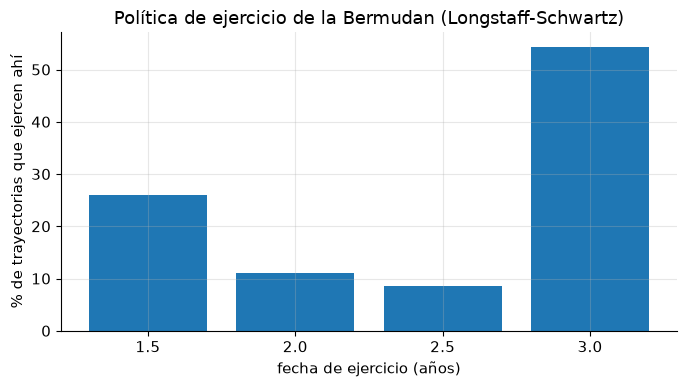

t=1.5: 25.9% de las trayectorias (temprano)
t=2.0: 11.1% de las trayectorias (temprano)
t=2.5: 8.6% de las trayectorias (temprano)
t=3.0: 54.4% de las trayectorias (ultima fecha / flujo final, incl. OTM=0)

La politica ejerce mas temprano cuando S ya esta suficientemente ITM: perder tiempo
adicional de opcionalidad no compensa el mayor valor intrinseco disponible ahora.


In [7]:
# exercise_idx == j+1 para j=0,1,2 son decisiones tempranas explicitas (n=3,4,5); el bucket
# exercise_idx == n_dates agrupa la ultima fecha (n=6) CON "nunca se ejercio antes" -- son la
# misma rama en Longstaff-Schwartz (ahi siempre se toma el flujo final, sea positivo o cero).
exercise_counts = np.array([(exercise_idx == j + 1).sum() for j in range(n_dates)])
fracs = exercise_counts / n_paths

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"{n*tau}" for n in N_EX], fracs * 100)
ax.set_xlabel("fecha de ejercicio (años)")
ax.set_ylabel("% de trayectorias que ejercen ahí")
ax.set_title("Política de ejercicio de la Bermudan (Longstaff-Schwartz)")
fig.tight_layout(); plt.show()

for j, n in enumerate(N_EX):
    label = "(temprano)" if n < N_EX[-1] else "(ultima fecha / flujo final, incl. OTM=0)"
    print(f"t={n*tau}: {fracs[j]:.1%} de las trayectorias {label}")
print("\nLa politica ejerce mas temprano cuando S ya esta suficientemente ITM: perder tiempo")
print("adicional de opcionalidad no compensa el mayor valor intrinseco disponible ahora.")

## 3. Comparación cualitativa: motor de un factor (Hull-White/Gsr vía QuantLib)

HW de 1 factor calibrado ATM a la misma superficie de caps (igual que 6.2) valuando la
**misma** Bermudan swaption con `ql.Gaussian1dSwaptionEngine`. HW de 1 factor y LMM
multi-factor no tienen por qué coincidir exactamente — la correlación imperfecta entre
tasas del LMM (Sección 2 de 7.3) reduce la volatilidad efectiva de la tasa swap frente a
un modelo de 1 factor (donde todas las tasas se mueven perfectamente correlacionadas), lo
cual generalmente abarata la opcionalidad en el LMM respecto al HW. Se reporta la
diferencia sin fijarle una tolerancia dura.

In [8]:
import QuantLib as ql

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
times_grid = np.linspace(1 / 365, 20.0, 400)
dfs_grid = nelson_siegel_df(times_grid)
dates_grid = [eval_date] + [eval_date + ql.Period(int(round(t * 365)), ql.Days) for t in times_grid]
curve_ql = ql.DiscountCurve(dates_grid, [1.0] + list(dfs_grid), day_count)
curve_ql.enableExtrapolation()
curve_handle = ql.YieldTermStructureHandle(curve_ql)


def df_ql(t):
    return curve_ql.discount(float(t))


def fwd_ql(t, eps=1e-5):
    return -(np.log(curve_ql.discount(t + eps)) - np.log(curve_ql.discount(t - eps))) / (2 * eps)


def bond_vol(t1, t2, a, sigma):
    return sigma / a * (1.0 - np.exp(-a * (t2 - t1))) * np.sqrt((1.0 - np.exp(-2 * a * t1)) / (2 * a))


def caplet_price_hw(t1, t2, K_, tau_, a, sigma):
    P0t1, P0t2 = df_ql(t1), df_ql(t2)
    sig_p = bond_vol(t1, t2, a, sigma)
    X = 1.0 / (1.0 + K_ * tau_)
    d1 = (np.log(P0t2 / (X * P0t1)) + 0.5 * sig_p ** 2) / sig_p
    d2 = d1 - sig_p
    return (1.0 + K_ * tau_) * (X * P0t1 * norm.cdf(-d2) - P0t2 * norm.cdf(-d1))


def black_caplet_price(t1, t2, K_, vol, tau_):
    F = (df_ql(t1) / df_ql(t2) - 1.0) / tau_
    d1 = (np.log(F / K_) + 0.5 * vol ** 2 * t1) / (vol * np.sqrt(t1))
    d2 = d1 - vol * np.sqrt(t1)
    return df_ql(t2) * tau_ * (F * norm.cdf(d1) - K_ * norm.cdf(d2))


target_caplets = np.array([black_caplet_price(T[i], T[i + 1], L0[i], cap_vols_atm[i], tau) for i in range(N)])


def resid_hw(params):
    a, sigma = params
    if a <= 0 or sigma <= 0:
        return np.full(N, 1e3)
    model = np.array([caplet_price_hw(T[i], T[i + 1], L0[i], tau, a, sigma) for i in range(N)])
    return (model - target_caplets) / target_caplets


fit = least_squares(resid_hw, x0=[0.05, 0.15], bounds=([1e-4, 1e-4], [2.0, 1.0]))
a_hw, sigma_hw = fit.x
print(f"HW calibrado (ATM caps, misma superficie que 7.3): a={a_hw:.5f}, sigma={sigma_hw:.5f}")

gsr = ql.Gsr(curve_handle, [], [ql.QuoteHandle(ql.SimpleQuote(sigma_hw))],
             [ql.QuoteHandle(ql.SimpleQuote(a_hw))])
swaption_engine = ql.Gaussian1dSwaptionEngine(gsr)

start_date = eval_date + ql.Period(int(round(N_EX[0] * tau * 365)), ql.Days)
maturity_date = eval_date + ql.Period(int(round(T[BETA_N] * 365)), ql.Days)
schedule = ql.Schedule(start_date, maturity_date, ql.Period(6, ql.Months), ql.NullCalendar(),
                        ql.Unadjusted, ql.Unadjusted, ql.DateGeneration.Forward, False)
index = ql.IborIndex("dummy", ql.Period(6, ql.Months), 0, ql.USDCurrency(), ql.NullCalendar(),
                      ql.Unadjusted, False, day_count, curve_handle)
swap = ql.VanillaSwap(ql.VanillaSwap.Receiver, 1.0, schedule, K, day_count, schedule, index, 0.0, day_count)
exercise_dates_ql = [eval_date + ql.Period(int(round(n * tau * 365)), ql.Days) for n in N_EX]
swaption_ql = ql.Swaption(swap, ql.BermudanExercise(exercise_dates_ql))
swaption_ql.setPricingEngine(swaption_engine)
price_ql_bermudan = swaption_ql.NPV()

rel_diff_hw = abs(price_ql_bermudan - price_bermudan) / price_bermudan
print(f"\nBermudan QuantLib (Gsr/HW 1-factor): {price_ql_bermudan:.6f}")
print(f"Bermudan propio (LMM multi-factor):  {price_bermudan:.6f}")
print(f"diferencia relativa: {rel_diff_hw:.1%} (sin tolerancia dura -- 1 factor vs multi-factor)")

HW calibrado (ATM caps, misma superficie que 7.3): a=0.00066, sigma=0.00751



Bermudan QuantLib (Gsr/HW 1-factor): 0.011722
Bermudan propio (LMM multi-factor):  0.009304
diferencia relativa: 26.0% (sin tolerancia dura -- 1 factor vs multi-factor)


## 4. Validación

Tres chequeos duros más una comparación cualitativa: (1) la swaption europea de la Demo 1 coincide con Black-76 dentro de 3 SE; (2) la Bermudan vale al menos tanto como la mejor europea, dentro del margen de error combinado; (3) el control de una sola fecha (Demo 3) reproduce el precio europeo exacto. La comparación contra el motor de un factor de la Sección 3 no lleva tolerancia dura — HW y LMM no tienen por qué coincidir, como se explicó ahí.

In [9]:
check1 = z_rebonato <= 3.0
print(f"1. europea MC vs Black-76 (vol Rebonato calibrada): z={z_rebonato:.2f} (<=3? {check1})")

check2 = check_bound
print(f"2. Bermudan >= mejor europea - 3SE: {check2} "
      f"(Bermudan-Europea={price_bermudan - price_european_best:.2e}, margen={margin:.2e})")

check3 = diff_control < 1e-8
print(f"3. control 1-fecha reproduce el europeo exacto: diff={diff_control:.2e} (<1e-8? {check3})")

print(f"\n4. [diagnostico, sin tolerancia dura] Bermudan LMM vs Gaussian1dSwaptionEngine (HW 1F): "
      f"diferencia relativa {rel_diff_hw:.1%}")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 checks duros dentro de tolerancia (mas 1 comparacion cualitativa).")

1. europea MC vs Black-76 (vol Rebonato calibrada): z=0.77 (<=3? True)
2. Bermudan >= mejor europea - 3SE: True (Bermudan-Europea=1.46e-03, margen=1.76e-04)
3. control 1-fecha reproduce el europeo exacto: diff=0.00e+00 (<1e-8? True)

4. [diagnostico, sin tolerancia dura] Bermudan LMM vs Gaussian1dSwaptionEngine (HW 1F): diferencia relativa 26.0%

Validacion completa: 3/3 checks duros dentro de tolerancia (mas 1 comparacion cualitativa).


## Referencias

- Longstaff, F.A. & Schwartz, E.S. (2001). *Valuing American Options by Simulation: A
  Simple Least-Squares Approach*. Review of Financial Studies, 14(1), 113-147 (reusado de
  4.4).
- Andersen, L. (2000). *A Simple Approach to the Pricing of Bermudan Swaptions in the
  Multifactor LIBOR Market Model*. Journal of Computational Finance, 3(2), 5-32.
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models — Theory and Practice*
  (2nd ed.), capítulo 6, §6.7.